# 04 — Prédiction de budget par segment (Random Forest)

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from pathlib import Path
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

BASE       = Path('d:/Smart-Free_GestionMess+Feedback/Smart-Free_GestionMess/ml-service')
MODELS_DIR = BASE / 'models'

# Charger données segmentées
df = pd.read_csv(BASE / 'data' / 'segmented.csv')
print('Shape :', df.shape)
print('Segments :', df['segment_label'].value_counts().to_dict())

Shape : (8871, 16)
Segments : {'High-Budget': 4404, 'Mid-Budget': 4135, 'Low-Budget': 182, 'Premium': 150}


In [9]:
# Filtrer les segments cohérents (exclure Premium outliers)
df = df[df['segment_label'].isin(['Low-Budget', 'Mid-Budget', 'High-Budget'])]
print('Après filtre Premium :', df.shape)
print(f"avg_price → min:{df['avg_price'].min():.0f}  max:{df['avg_price'].max():.0f}  mean:{df['avg_price'].mean():.0f}")

Après filtre Premium : (8721, 16)
avg_price → min:5  max:35000  mean:1785


In [10]:
# TF-IDF sur les tags
tfidf = TfidfVectorizer(max_features=150, ngram_range=(1,2))
X_tags = tfidf.fit_transform(df['tags_clean'].fillna('')).toarray()

# Encoder segment
seg_map = {'Low-Budget': 0, 'Mid-Budget': 1, 'High-Budget': 2}
X_seg  = df['segment_label'].map(seg_map).values.reshape(-1,1)

# rate_type
X_rate = (df['rate_type'] == 'hourly').astype(int).values.reshape(-1,1)

# Combiner features
X = np.hstack([X_tags, X_seg, X_rate])
y = df['avg_price'].values
print('X shape :', X.shape)

X shape : (8721, 152)


In [11]:
# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
print(f'Train: {X_train.shape} | Test: {X_test.shape}')

# Entraîner
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=20,
    min_samples_leaf=3,
    n_jobs=-1,
    random_state=42
)
rf.fit(X_train, y_train)
print('Modele entraine')

Train: (6976, 152) | Test: (1745, 152)
Modele entraine


In [12]:
# Évaluer
preds = rf.predict(X_test)
mae = mean_absolute_error(y_test, preds)
r2  = r2_score(y_test, preds)
print(f'MAE : {mae:.2f}$')
print(f'R2  : {r2:.4f}')

MAE : 2516.29$
R2  : 0.0075


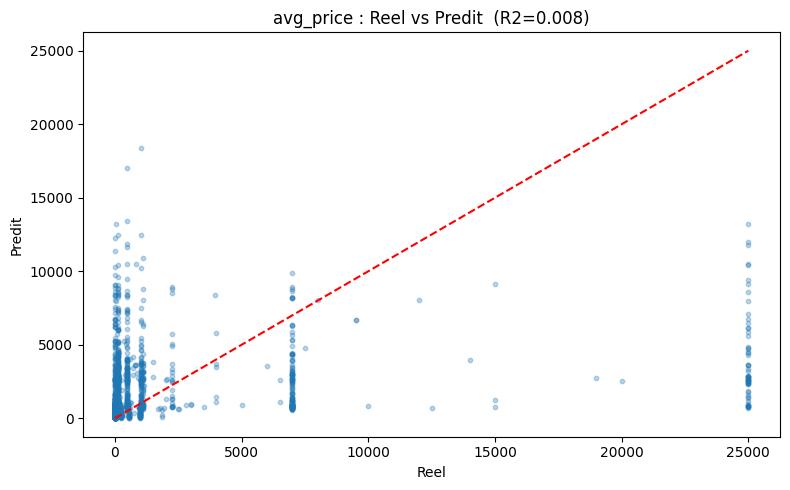

In [13]:
# Graphique Réel vs Prédit
plt.figure(figsize=(8,5))
plt.scatter(y_test, preds, alpha=0.3, s=10)
m = max(y_test.max(), preds.max())
plt.plot([0,m],[0,m],'r--')
plt.xlabel('Reel'); plt.ylabel('Predit')
plt.title(f'avg_price : Reel vs Predit  (R2={r2:.3f})')
plt.tight_layout(); plt.show()

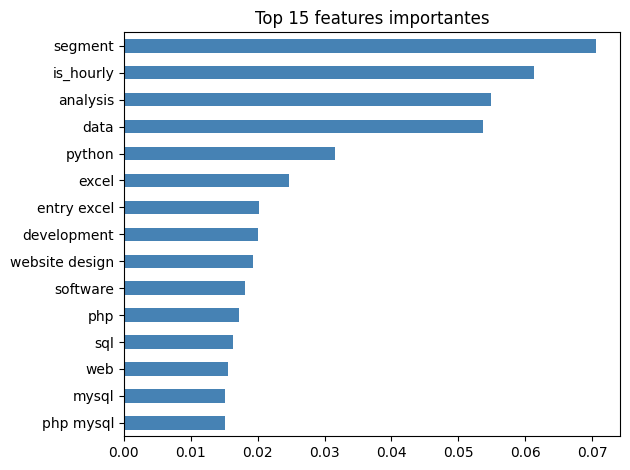

In [14]:
# Top features importantes
feat_names = tfidf.get_feature_names_out().tolist() + ['segment', 'is_hourly']
importances = pd.Series(rf.feature_importances_, index=feat_names)
importances.sort_values(ascending=False).head(15).plot(kind='barh', color='steelblue')
plt.title('Top 15 features importantes')
plt.gca().invert_yaxis()
plt.tight_layout(); plt.show()

In [15]:
# Sauvegarder
joblib.dump(rf,    MODELS_DIR / 'rf_avg.pkl')
joblib.dump(tfidf, MODELS_DIR / 'tfidf.pkl')
print('Sauvegardes OK : models/rf_avg.pkl  tfidf.pkl')

Sauvegardes OK : models/rf_avg.pkl  tfidf.pkl
